In [ ]:
import spacy
from spacy import displacy
from spacy.tokens import Doc
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay


# Load the large English model
nlp = spacy.load("en_core_web_lg")

Visualizing how spaCy processes the sentences and created the Dependency Tree

In [8]:
# Read the test data
test_data = pd.read_csv('C:/Users/ntanavarass/Desktop/Conversational-Triple-Extraction/final data/expanded_test_data.csv')

# Retrieve the first sentence of the test data
first_sentence = test_data['sentence'].iloc[0] 

# Process the sentence with spaCy
doc = nlp(first_sentence)

# Identify the root of the sentence (the main verb or predicate)
root = [token for token in doc if token.head == token]

# Define visual options for displacy
options = {
    "bg": "#ffffff",  # white background
    "color": "#000000",  # black text color
    "dep": "#0000ff",  # blue dependency arrows
    "font": "Calibri",
    "add_lemma": True,  # Adds lemmas to the tokens in the display
    "fine_grained": True,  # Shows fine-grained part of speech tags
    "collapse_punct": False,  # Collapses punctuation
    "collapse_phrases": False,  # Collapses phrases
    "distance": 100,  # Controls the distance between tokens in the diagram
}

# Find the root token
root = next(token for token in doc if token.dep_ == "ROOT")

# Visualize the dependency tree
displacy.render(doc, style='dep', jupyter=True, options=options)

# Print information about the root to the console
print(f"The root token is '{root.text}', which is typically the main verb or predicate of the sentence.")

The root token is 'facing', which is typically the main verb or predicate of the sentence.


SPO-label Extraction

In [9]:

def create_doc_from_tokens(nlp, tokens):
    """
    Create a spaCy Doc object from pre-tokenized words.
    Assumes no spaces between tokens to align exactly with the tokenized input.

    """
    spaces = [False] * (len(tokens) - 1) + [False]  # No space after each word
    doc = Doc(nlp.vocab, words=tokens, spaces=spaces)
    return doc


def apply_pipeline_except_tokenizer(doc):
    """
    Apply all pipeline components except tokenizer to a doc.

    """
    for name, proc in nlp.pipeline:
        if name != 'tokenizer':  # Skip tokenizer
            doc = proc(doc)
    return doc


def syntactic_parsing(tokens):
    """
    Processes the pre-tokenized data using spaCy while skipping its tokenizer.

    """
    # Create a doc with pre-tokenized data
    doc = create_doc_from_tokens(nlp, tokens)

    # Apply the rest of the pipeline components to the doc
    doc = apply_pipeline_except_tokenizer(doc)

    # Extract features and labels based on dependency parsing
    labels = ['other'] * len(doc)  # Initialize labels as 'other'
    for token in doc:
        # Handle predicates, especially the root
        if token.dep_ == 'ROOT' or token.dep_ in ['aux', 'auxpass', 'neg']:
            labels[token.i] = 'Predicate'

        # Handle subjects and extend to their subtree
        if token.dep_ in ['nsubj', 'nsubjpass']:
            labels[token.i] = 'Subject'
            for tok in token.subtree:
                if tok != token:
                    labels[tok.i] = 'Subject'

        # Handle objects and extend to their subtree
        if token.dep_ in ['dobj', 'pobj', 'attr']:
            labels[token.i] = 'Object'
            for tok in token.subtree:
                if tok != token:
                    labels[tok.i] = 'Object'

    return labels


def assign_label(df):
    """
    Assign SPO labels to each token in the DataFrame using pre-tokenized inputs.

    """
    # Create empty lists to hold data for the new DataFrame
    sentence_ids = []
    token_ids = []
    sentences = []
    tokens = []
    predicted_labels = []

    # Iterate over each unique sentence_id in the DataFrame
    for sentence_id, group in df.groupby('sentence_id'):
        token_list = group['token'].tolist()
        labels_for_sentence = syntactic_parsing(token_list)

        # Extend the lists with the data from the current group
        sentence_ids.extend([sentence_id] * len(token_list))
        token_ids.extend(group['token_id'].tolist())
        sentences.extend([group['sentence'].iloc[0]] * len(token_list))
        tokens.extend(token_list)
        predicted_labels.extend(labels_for_sentence)

    # Creating a new DataFrame to ensure all columns are correctly aligned and named.
    new_df = pd.DataFrame({
        'sentence_id': sentence_ids,
        'token_id': token_ids,
        'sentence': sentences,
        'token': tokens,
        'spo_label': predicted_labels
    })
    return new_df


Main Execution

In [11]:
# Assign labels
predictions_df = assign_label(test_data)
predictions_df.to_csv('C:/Users/ntanavarass/Desktop/Conversational-Triple-Extraction/cte/rule-based syntactic parsing/results/syntactic_parsing_results.csv')


Evaluation

Precision: 0.5447
Recall: 0.5694
F1 Score: 0.5502


<Figure size 1000x1000 with 0 Axes>

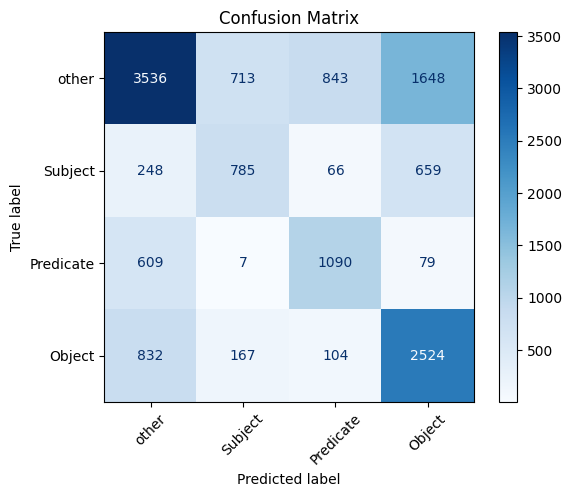

In [4]:
# Read the test data
test_data = pd.read_csv('C:/Users/Stelios_Ntanavaras/Desktop/Conversational-Triple-Extraction/final data/expanded_test_data.csv')

syntactic_parsing_predictions = pd.read_csv('C:/Users/Stelios_Ntanavaras/Desktop/Conversational-Triple-Extraction/cte/rule-based syntactic parsing/results/syntactic_parsing_results.csv')

# Make sure both dataframes are sorted by sentence_id and token_id to align them correctly
test_data.sort_values(by=['sentence_id', 'token_id'], inplace=True)
syntactic_parsing_predictions.sort_values(by=['sentence_id', 'token_id'], inplace=True)

# Check if both DataFrames have the same order
if not test_data[['sentence_id', 'token_id']].equals(syntactic_parsing_predictions[['sentence_id', 'token_id']]):
    raise ValueError("The order of rows in the test data and predictions does not match.")

# Calculate Precision, Recall, and F1-Score
metrics = precision_recall_fscore_support(test_data['spo_label'], syntactic_parsing_predictions['spo_label'], average='macro')
precision, recall, f1_score, _ = metrics

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

# Generate Confusion Matrix
cm = confusion_matrix(test_data['spo_label'], syntactic_parsing_predictions['spo_label'], labels=pd.unique(test_data['spo_label']))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pd.unique(test_data['spo_label']))

# Plot Confusion Matrix
plt.figure(figsize=(10,10))
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.title('Confusion Matrix')
plt.show()